
# Netflix Data — Cleaning, Analysis & Visualization (End-to-End Project)

Goal:  Clean and analyze Netflix titles to uncover trends across content type, ratings, genres, countries, and time.

List of goal :
1. Setup & Data Load  
2. Data Understanding & Quality Checks  
3. Cleaning (nulls, duplicates, types, splits)  
4. Enrichment (duration minutes/seasons, year/month/day, main country, genres list)  
5. Exploratory Data Analysis (EDA)  
6. Insights Summary & Next Steps

> Dataset: `netflix1.csv` (provided).


In [5]:

# === 1) Setup ===
import os, re, math, json, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['axes.grid'] = True

DATA_PATH = r"D:\Project UML\Netflix Data Cleaning, Analysis and Visualization\netflix1.csv"

assert os.path.exists(DATA_PATH), f"Dataset not found at: {DATA_PATH}"

print("Using DATA_PATH:", DATA_PATH)



Using DATA_PATH: D:\Project UML\Netflix Data Cleaning, Analysis and Visualization\netflix1.csv


In [6]:

# === 2) Data Load ===
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [7]:

# === 3) Data Understanding & Quality Checks ===
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'null_%': (df.isna().mean()*100).round(2)
}).sort_index()
display(summary)
print('\nDuplicates:', df.duplicated().sum())


,dtype,n_unique,null_%
country,object,86,0.0
date_added,object,1713,0.0
director,object,4528,0.0
duration,object,220,0.0
listed_in,object,513,0.0
rating,object,14,0.0
release_year,int64,74,0.0
show_id,object,8790,0.0
title,object,8787,0.0
type,object,2,0.0



Duplicates: 0



## Cleaning Plan
- Drop exact duplicates  
- Standardize and parse `date_added` to datetime  
- Strip whitespace from text columns  
- Handle missing/placeholder values (`Not Given`) for key columns  
- Normalize `rating` text  
- Split `listed_in` (genres) into lists  
- Parse `duration` into minutes and seasons


In [8]:

# === 4) Cleaning ===

# 4.1 Drop duplicates
df = df.drop_duplicates().copy()

# 4.2 Trim whitespace in object columns
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

# 4.3 Parse dates
if 'date_added' in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 4.4 Normalize simple placeholders
for col in ['director','country','rating','listed_in']:
    if col in df.columns:
        df[col] = df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})

# 4.5 Normalize ratings (upper-case, strip)
if 'rating' in df.columns:
    df['rating'] = df['rating'].str.upper().str.replace(' ', '', regex=False)

# 4.6 Split genres into list
def split_genres(x):
    if pd.isna(x): return []
    return [g.strip() for g in str(x).split(',') if g.strip()!='']

df['genres_list'] = df['listed_in'].apply(split_genres) if 'listed_in' in df.columns else [[]]

# 4.7 Parse duration into minutes and seasons
def parse_duration(raw):
    if pd.isna(raw):
        return (np.nan, np.nan)
    s = str(raw).strip()
    m = re.match(r'(?i)^(\d+)\s*min', s)
    if m:
        return (int(m.group(1)), 0)
    m2 = re.match(r'(?i)^(\d+)\s*season', s)
    if m2:
        return (0, int(m2.group(1)))
    return (np.nan, np.nan)

if 'duration' in df.columns:
    mins, seasons = zip(*df['duration'].map(parse_duration))
    df['duration_minutes'] = mins
    df['seasons'] = seasons

# 4.8 Derive date parts
if 'date_added' in df.columns:
    df['year_added'] = df['date_added'].dt.year
    df['month_added'] = df['date_added'].dt.month
    df['day_added'] = df['date_added'].dt.day

# 4.9 Main country (first in list)
def first_country(x):
    if pd.isna(x): 
        return np.nan
    parts = [p.strip() for p in str(x).split(',') if p.strip()!='']
    return parts[0] if parts else np.nan

if 'country' in df.columns:
    df['main_country'] = df['country'].apply(first_country)

print('✅ Cleaning complete.')
df.head()


✅ Cleaning complete.


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,genres_list,duration_minutes,seasons,year_added,month_added,day_added,main_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,[Documentaries],90,0,2021,9,25,United States
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac...",0,1,2021,9,24,France
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries","[TV Dramas, TV Horror, TV Mysteries]",0,1,2021,9,24,United States
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies","[Children & Family Movies, Comedies]",91,0,2021,9,22,Brazil
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","[Dramas, Independent Movies, International Mov...",125,0,2021,9,24,United States



## Exploratory Data Analysis (EDA)
- Content Type distribution  
- Ratings distribution  
- Top countries  
- Content added over time (monthly & yearly)  
- Top genres (overall)  
- Top directors  
- Title word cloud (optional)


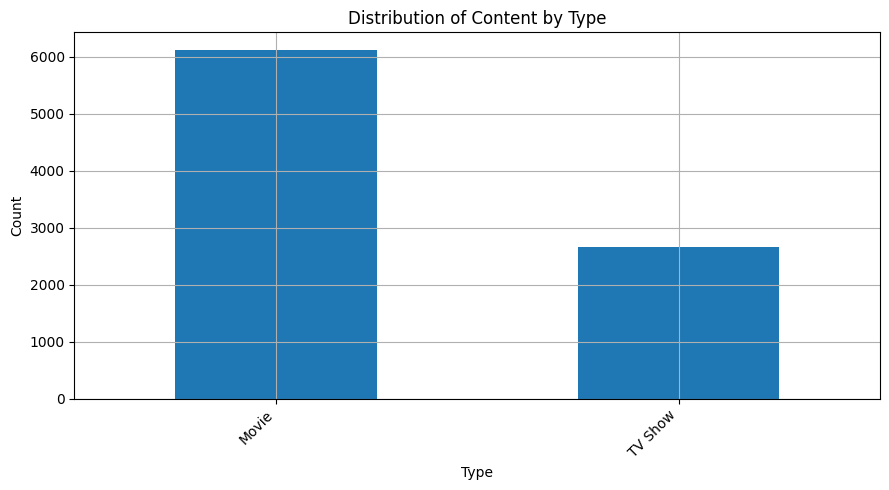

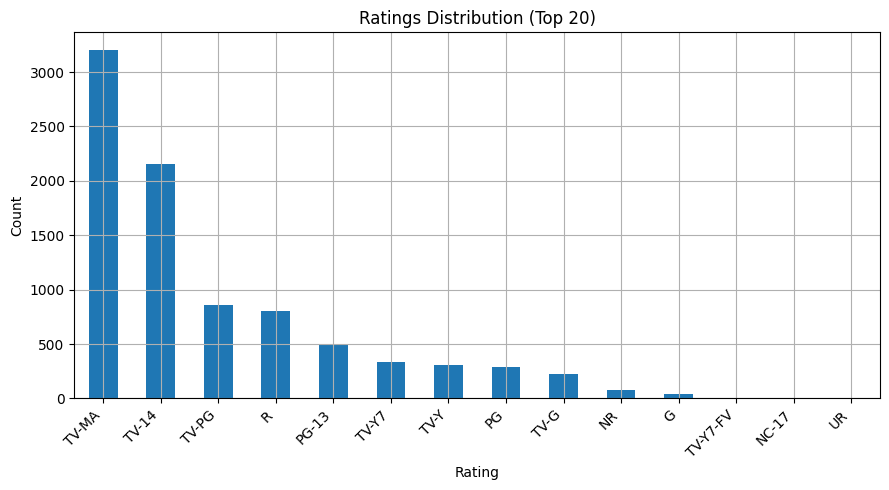

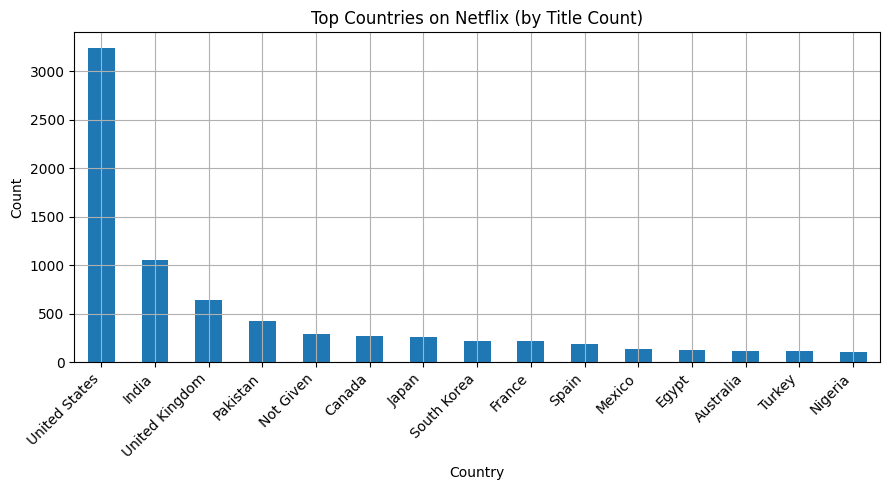

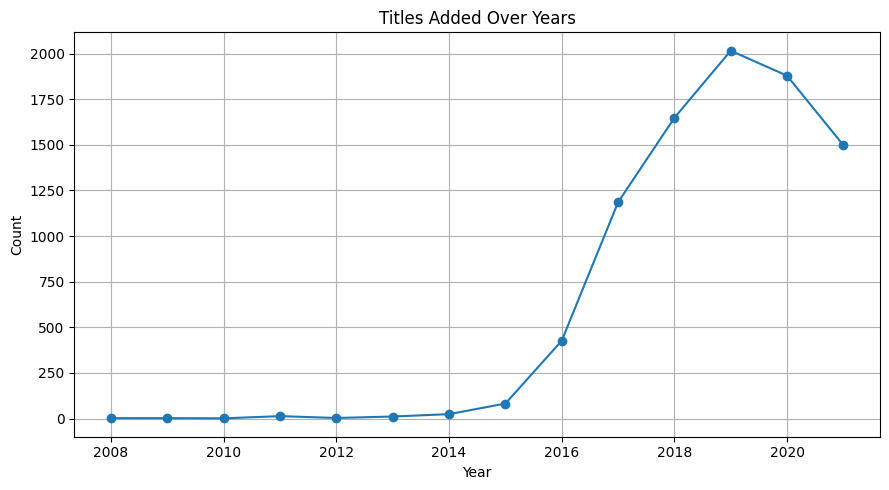

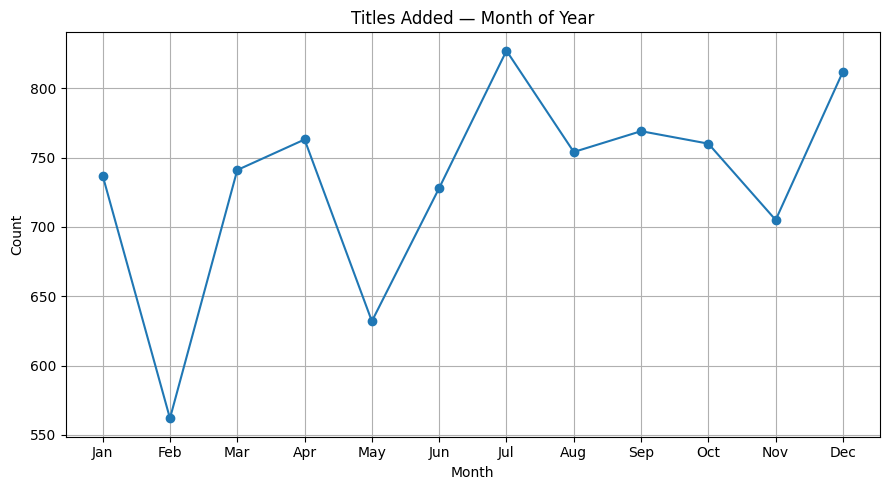

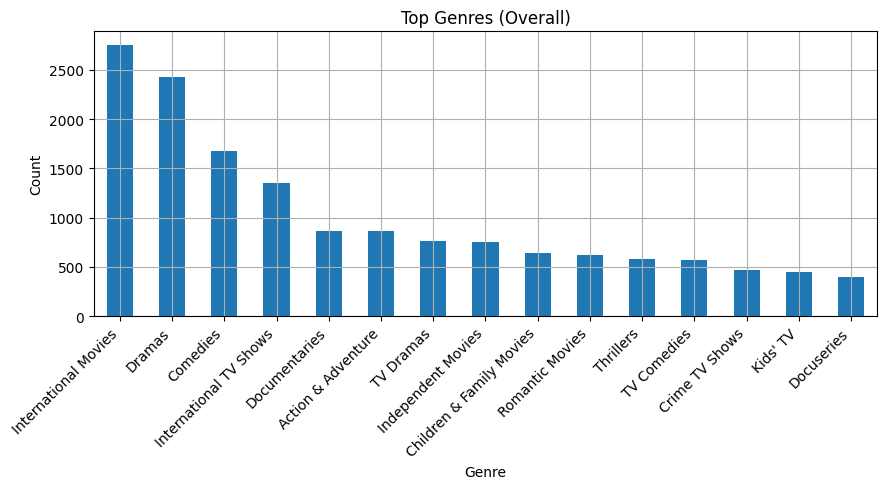

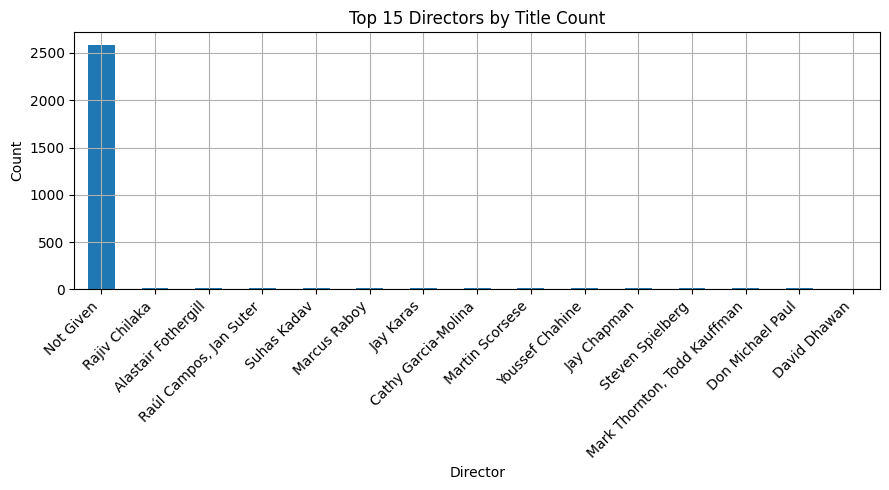

In [9]:

# === 5) EDA ===
import itertools
from collections import Counter

def bar_from_series(s, title, xlabel='', ylabel='Count', rotate=45):
    fig, ax = plt.subplots()
    s.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotate, ha='right')
    plt.tight_layout(); plt.show()

# 5.1 Content Type distribution
if 'type' in df.columns:
    type_counts = df['type'].value_counts().sort_values(ascending=False)
    bar_from_series(type_counts, 'Distribution of Content by Type', xlabel='Type')

# 5.2 Ratings distribution
if 'rating' in df.columns:
    rating_counts = df['rating'].value_counts().sort_values(ascending=False).head(20)
    bar_from_series(rating_counts, 'Ratings Distribution (Top 20)', xlabel='Rating')

# 5.3 Top countries
if 'main_country' in df.columns:
    top_countries = df['main_country'].value_counts().head(15)
    bar_from_series(top_countries, 'Top Countries on Netflix (by Title Count)', xlabel='Country')

# 5.4 Over time
if 'year_added' in df.columns:
    yearly = df['year_added'].value_counts().sort_index()
    fig, ax = plt.subplots()
    ax.plot(yearly.index, yearly.values, marker='o')
    ax.set_title('Titles Added Over Years'); ax.set_xlabel('Year'); ax.set_ylabel('Count')
    plt.tight_layout(); plt.show()

if 'month_added' in df.columns:
    monthly = df['month_added'].value_counts().sort_index()
    fig, ax = plt.subplots()
    ax.plot(monthly.index, monthly.values, marker='o')
    ax.set_title('Titles Added — Month of Year'); ax.set_xlabel('Month'); ax.set_ylabel('Count')
    ax.set_xticks(range(1,13)); 
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.tight_layout(); plt.show()

# 5.5 Genres (overall top)
genre_counts = Counter(itertools.chain.from_iterable(df['genres_list']))
genre_counts_overall = pd.Series(genre_counts).sort_values(ascending=False).head(15)
bar_from_series(genre_counts_overall, 'Top Genres (Overall)', xlabel='Genre')

# 5.6 Top directors
if 'director' in df.columns:
    top_directors = df['director'].value_counts().head(15)
    bar_from_series(top_directors, 'Top 15 Directors by Title Count', xlabel='Director')


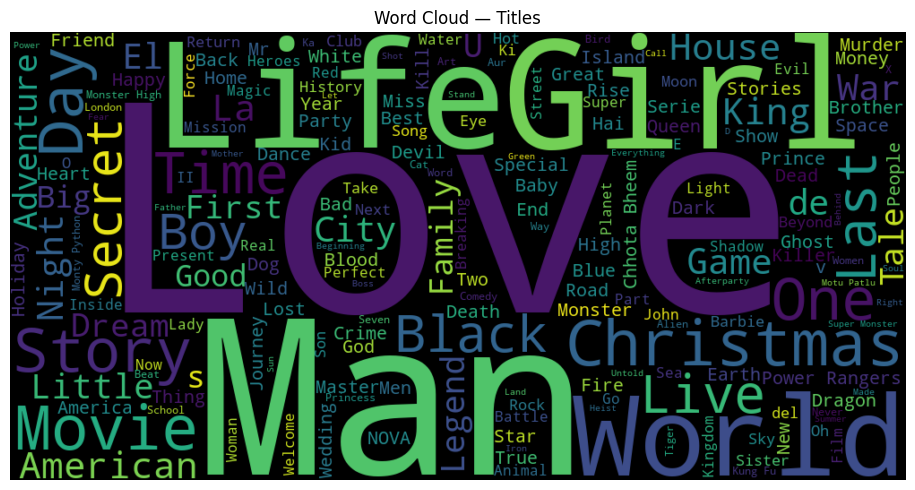

In [11]:

#  Optional: Title Word Cloud 
try:
    from wordcloud import WordCloud
    titles = df['title'].dropna().astype(str).tolist() if 'title' in df.columns else []
    if len(titles) > 0:
        text = " ".join(titles)
        wc = WordCloud(width=1000, height=500, background_color='black').generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud — Titles')
        plt.tight_layout(); plt.show()
    else:
        print('No titles available for word cloud.')
except Exception as e:
    print('Skipping word cloud (install `wordcloud` to enable). Error:', e)



 Insights Summary
- Type mix: Movies typically outnumber TV Shows; verify exact split above.  
- Ratings: TV-MA/TV-14 often dominate; check top bars to confirm.  
- Countries: A handful of countries contribute the bulk of titles (e.g., US, India, UK).  
- Time trends: Significant growth after ~2015; monthly seasonality possible.  
- Genres: A small set of genres (e.g., International TV Shows, Dramas, Comedies) dominate.
